### Inertia Forecasting — Cardinality-Constrained Sparse Regression

$$\min_{\beta_0,\boldsymbol{\beta},\mathbf{z}}\;\sum_{t=1}^{T}\!\left(I_t - \beta_0 - \boldsymbol{\beta}^\top\boldsymbol{\phi}_t\right)^2\quad\text{s.t.}\quad\textstyle\sum_j z_j \le K,\;{-M_\beta z_j \le \beta_j \le M_\beta z_j},\;z_j\in\{0,1\}$$

In [39]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/home/alireza/Desktop/inertia'

plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     12,
    'axes.titleweight':   'bold',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '0.8',
    'figure.dpi':         120,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    1.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.05,
})

PALETTE  = {'ERCOT': '#1565C0', 'GB': '#B71C1C', 'Nordic': '#1B5E20'}
PALETTE2 = {'ERCOT': '#90CAF9', 'GB': '#EF9A9A', 'Nordic': '#A5D6A7'}
MARKERS  = {'ERCOT': 'o', 'GB': 's', 'Nordic': '^'}
print('Environment ready.')

Environment ready.


## 1 · Data Loading

In [40]:
def load_system(name):
    files = {'ERCOT':'ercot_inertia.csv','GB':'inertia_GB.csv','Nordic':'inertia_nordic.csv'}
    df = pd.read_csv(f"{DATA_DIR}/{files[name]}")
    df['time'] = pd.to_datetime(df['time'])
    if 'forecast_other_genration' in df.columns:
        df = df.rename(columns={'forecast_other_genration':'forecast_other_generation'})
    if name in ('GB','Nordic'):
        df['inertia'] = df['inertia'] * 1e3
    key_cols = ['inertia','forecast_load','forecast_wind','forecast_solar','forecast_other_generation']
    return df.dropna(subset=key_cols).reset_index(drop=True)

systems = {n: load_system(n) for n in ['ERCOT','GB','Nordic']}
print(f"{'System':<8} {'Rows':>6}  {'Min (MWs)':>14}  {'Max (MWs)':>14}  Date range")
print('-'*72)
for n, df in systems.items():
    print(f"{n:<8} {len(df):>6}  {df.inertia.min():>14,.0f}  "
          f"{df.inertia.max():>14,.0f}  "
          f"{df.time.min().date()} to {df.time.max().date()}")

System     Rows       Min (MWs)       Max (MWs)  Date range
------------------------------------------------------------------------
ERCOT      8751         109,599         381,261  2021-01-01 to 2022-01-01
GB         7864         131,000         380,000  2020-06-01 to 2021-05-31
Nordic     8653         110,000         256,000  2021-01-01 to 2021-12-31


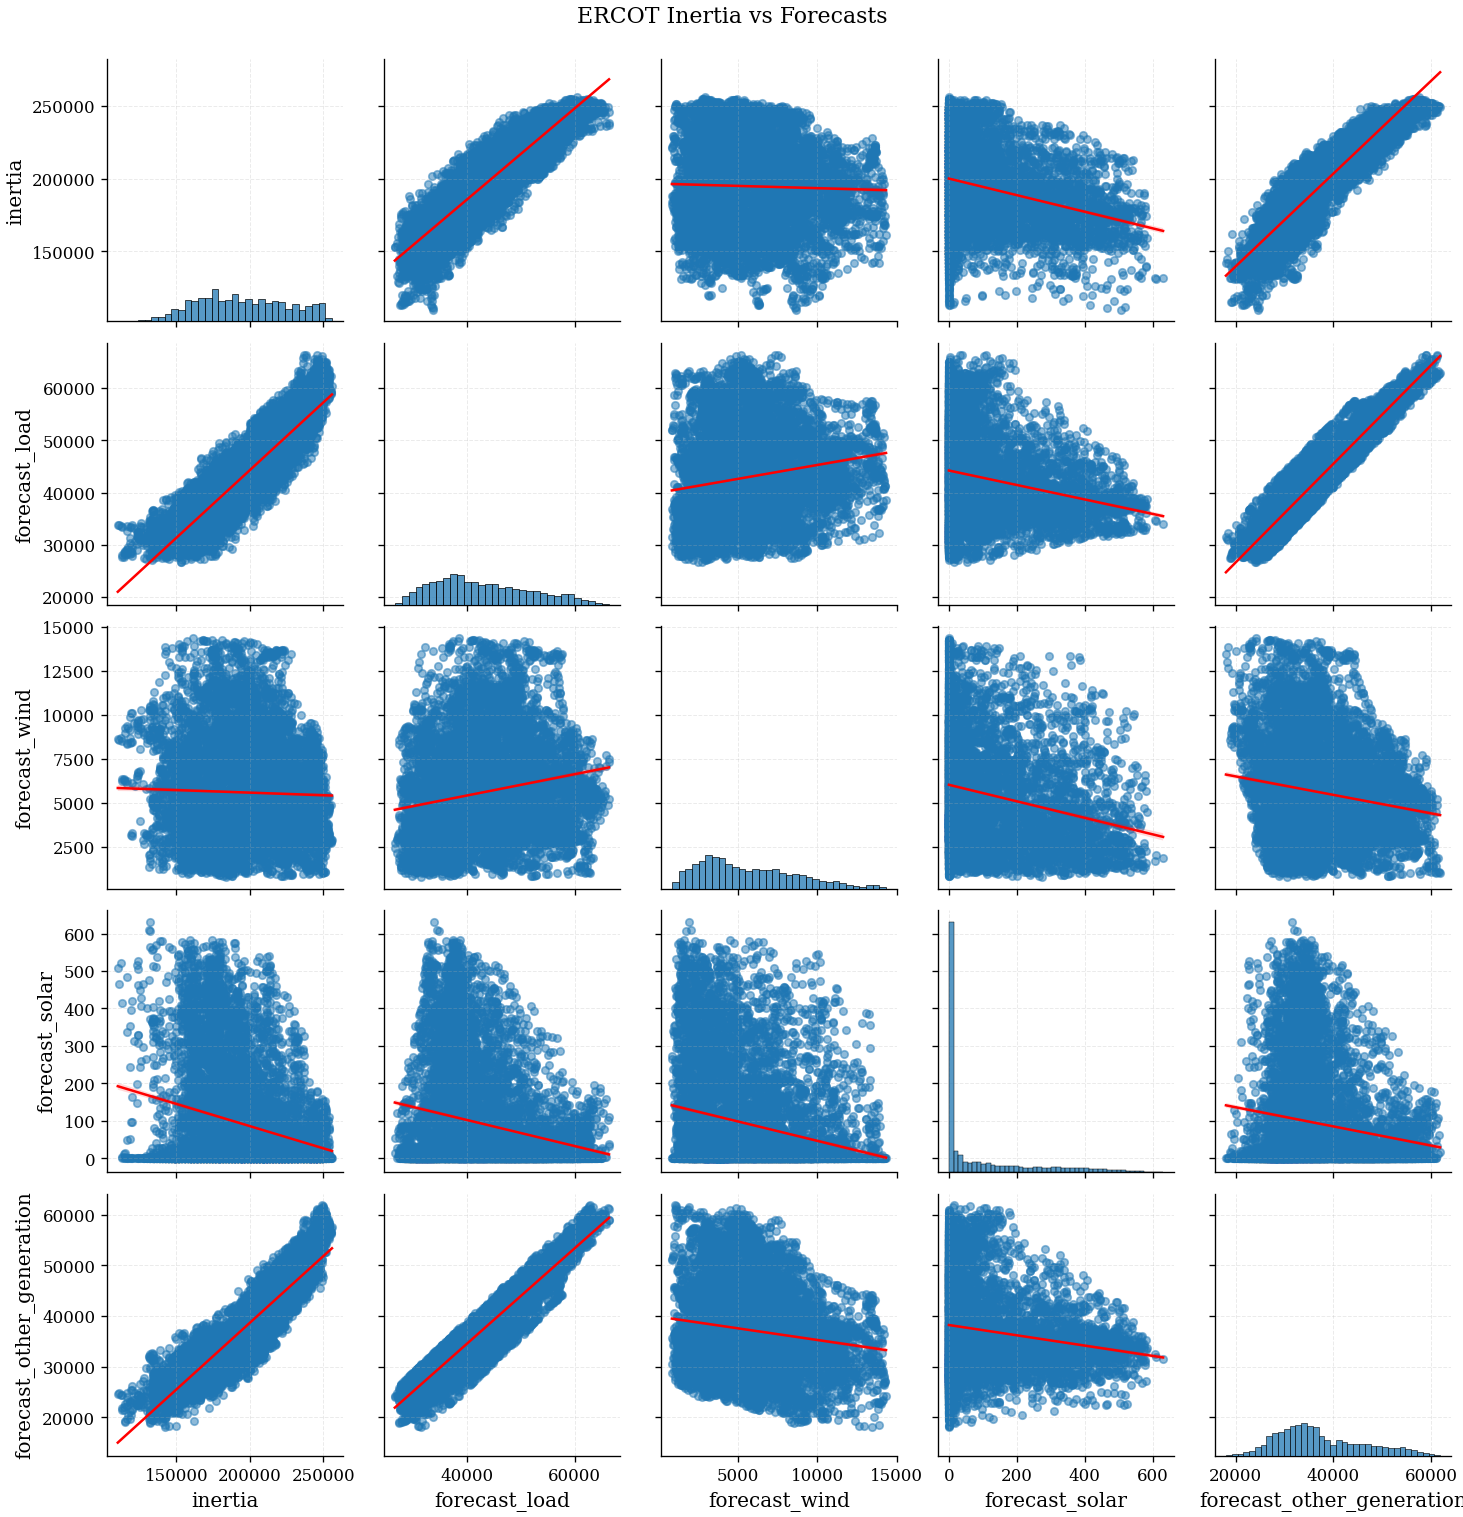

In [41]:
import seaborn as sns
sns.pairplot(systems['Nordic'][['inertia','forecast_load','forecast_wind','forecast_solar','forecast_other_generation']], kind='reg', plot_kws={'line_kws':{'color':'red','lw':1.5}, 'scatter_kws':{'alpha':0.5,'s':20}})
plt.suptitle('ERCOT Inertia vs Forecasts', y=1.02)
plt.show()

## 2 · Feature Engineering

Candidate feature vector $\boldsymbol{\phi}_t \in \mathbb{R}^{24}$ ($p=24$):

| Group | Features | Count |
|---|---|---|
| Load family | $P^L$, $(P^L)^2$, $\sqrt{P^L}$, $\log P^L$ | 4 |
| Wind family | same 4 transforms of $P^W$ | 4 |
| Solar family | same 4 transforms of $P^S$ | 4 |
| Other-gen family | same 4 transforms of $P^O$ | 4 |
| Calendar | $\sin/\cos$ of hour, day-of-week, month | 6 |
| AR lags | $I_{t-1}$, $I_{t-24}$ | 2 |

In [42]:
def build_features(df, eps=1.0):
    t     = df['time']
    I_raw = df['inertia'].values.astype(float)
    base_vars = {
        'load':      df['forecast_load'].values.clip(0),
        'wind':      df['forecast_wind'].values.clip(0),
        'solar':     df['forecast_solar'].values.clip(0),
        'other_gen': df['forecast_other_generation'].values.clip(0),
    }
    cols, names, groups, transform_sets = [], [], {}, []
    for var_name, x in base_vars.items():
        g_idx, t_idx = [], []
        for suffix, arr in [(var_name, x), (f'{var_name}^2', x**2),
                            (f'sqrt_{var_name}', np.sqrt(x)),
                            (f'log_{var_name}', np.log(x + eps))]:
            cols.append(arr); names.append(suffix)
            idx = len(cols)-1; g_idx.append(idx); t_idx.append(idx)
        groups[f'G_{var_name}'] = g_idx
        transform_sets.append(t_idx)
    hour = t.dt.hour.values; dow = t.dt.dayofweek.values; month = t.dt.month.values
    cal_s = len(cols)
    for suffix, arr in [('sin_hour', np.sin(2*np.pi*hour/24)),
                        ('cos_hour', np.cos(2*np.pi*hour/24)),
                        ('sin_dow',  np.sin(2*np.pi*dow/7)),
                        ('cos_dow',  np.cos(2*np.pi*dow/7)),
                        ('sin_month',np.sin(2*np.pi*month/12)),
                        ('cos_month',np.cos(2*np.pi*month/12))]:
        cols.append(arr); names.append(suffix)
    groups['G_calendar'] = list(range(cal_s, len(cols)))
    lag_s = len(cols)
    Is = pd.Series(I_raw)
    cols.append(Is.shift(1).bfill().values);  names.append('I_lag1')
    cols.append(Is.shift(24).bfill().values); names.append('I_lag24')
    groups['G_lags'] = list(range(lag_s, len(cols)))
    return np.column_stack(cols).astype(float), I_raw, names, groups, transform_sets

feat_data = {}
for sname in systems:
    Phi, I_vec, feat_names, grps, tsets = build_features(systems[sname])
    feat_data[sname] = dict(Phi=Phi, I_vec=I_vec, feat_names=feat_names,
                            groups=grps, transform_sets=tsets)
    print(f"{sname}: shape={Phi.shape}")

ERCOT: shape=(8751, 24)
GB: shape=(7864, 24)
Nordic: shape=(8653, 24)


## 3 · Train / Validation / Test Split

| Split | Fraction | Role |
|---|---|---|
| **Train** | 70% | Fit MIQP coefficients |
| **Validation** | 15% | Independent generalisation check |
| **Test** | 15% | One-shot final evaluation (never used during tuning) |

$K^\star$ is selected by minimising the mean CV-RMSE across 3 `TimeSeriesSplit` folds on the **training** set only.

In [43]:
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

splits = {}
for sname in systems:
    d = feat_data[sname]
    T = len(d['I_vec'])
    n_tr  = int(T * TRAIN_FRAC)
    n_val = int(T * VAL_FRAC)
    splits[sname] = {
        'Phi_tr': d['Phi'][:n_tr],           'I_tr': d['I_vec'][:n_tr],
        'Phi_va': d['Phi'][n_tr:n_tr+n_val], 'I_va': d['I_vec'][n_tr:n_tr+n_val],
        'Phi_te': d['Phi'][n_tr+n_val:],     'I_te': d['I_vec'][n_tr+n_val:],
        'n_tr': n_tr, 'n_val': n_val, 'n_te': T-n_tr-n_val, 'T': T,
        'time': systems[sname]['time'].values,
    }
    print(f"{sname}: train={n_tr}  val={n_val}  test={T-n_tr-n_val}  total={T}")

ERCOT: train=6125  val=1312  test=1314  total=8751
GB: train=5504  val=1179  test=1181  total=7864
Nordic: train=6057  val=1297  test=1299  total=8653


## 4 · MIQP Solver (Gurobi)

In [44]:
def fit_miqp(Phi_tr, I_tr, K=5, M_beta=10.0, time_limit=60.0, verbose=False):
    T, p   = Phi_tr.shape
    phi_mu = Phi_tr.mean(0); phi_sg = Phi_tr.std(0).clip(1e-8)
    I_mu   = I_tr.mean();    I_sg   = I_tr.std()
    Phis   = (Phi_tr - phi_mu) / phi_sg
    Is     = (I_tr  - I_mu)   / I_sg
    Phi_aug = np.column_stack([np.ones(T), Phis])
    
    Q = Phi_aug.T @ Phi_aug
    c = -2.0 * (Phi_aug.T @ Is)
    
    m = gp.Model('miqp')
    m.Params.OutputFlag   = int(verbose)
    m.Params.TimeLimit    = time_limit
    m.Params.MIPGap       = 1e-4
    m.Params.NumericFocus = 1
    
    theta = m.addMVar(p+1, lb=-GRB.INFINITY, name='theta')
    z     = m.addMVar(p,   vtype=GRB.BINARY,  name='z')
    
    m.setObjective(theta @ Q @ theta + c @ theta, GRB.MINIMIZE)
    m.addConstr(z.sum()    <= K,          name='card')
    m.addConstr(theta[1:] <=  M_beta * z, name='bigM_u')
    m.addConstr(theta[1:] >= -M_beta * z, name='bigM_l')
    m.optimize()
    
    if m.Status not in (GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL): return None
    th    = theta.X
    beta  = I_sg * th[1:] / phi_sg
    
    beta0 = I_mu + I_sg*th[0] - (beta * phi_mu).sum()
    
    return {'beta0': beta0, 'beta': beta,
            'selected': np.where(z.X.round()==1)[0],
            'status': m.Status, 'mip_gap': m.MIPGap}


def predict(Phi, p): return p['beta0'] + Phi @ p['beta']


def metrics(I_true, I_hat):
    res   = I_true - I_hat
    rmse  = np.sqrt((res**2).mean())
    mae   = np.abs(res).mean()
    mape  = (np.abs(res) / np.abs(I_true).clip(1)).mean() * 100
    r2    = 1 - (res**2).sum() / ((I_true-I_true.mean())**2).sum()
    nrmse = rmse / I_true.mean() * 100
    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2, nrmse=nrmse, res=res, I_hat=I_hat)

print('Solver and metric utilities defined.')

Solver and metric utilities defined.


## 5 · Sparsity Tuning via K-Fold Cross-Validation

For each $K \in \{1,\ldots,15\}$ and each system, **3-fold `TimeSeriesSplit`** (expanding window) is run on the training set. The fold-averaged validation RMSE identifies $K^\star = \arg\min_K \overline{\text{RMSE}}_{\text{CV}}(K)$.

In [45]:
K_RANGE  = list(range(1, 16))
N_SPLITS = 3
M_BETA   = 10.0
TL_CV    = 45.0
TL_FINAL = 120.0

cv_records = {}

for sname in ['ERCOT','GB','Nordic']:
    print(f"\n{'=':=>56}")
    print(f"  {sname}  |  K-fold CV  (n_splits={N_SPLITS})")
    print(f"{'=':=>56}")
    Phi_tr = splits[sname]['Phi_tr']; I_tr = splits[sname]['I_tr']
    tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
    cv_m, cv_s, tr_r = [], [], []

    for K in K_RANGE:
        fold_rmse = []
        for fi, vi in tscv.split(Phi_tr):
            p = fit_miqp(Phi_tr[fi], I_tr[fi], K=K, M_beta=M_BETA, time_limit=TL_CV)
            if p is None:
                fold_rmse.append(np.nan); continue
            fold_rmse.append(np.sqrt(((I_tr[vi] - predict(Phi_tr[vi], p))**2).mean()))
        p_full = fit_miqp(Phi_tr, I_tr, K=K, M_beta=M_BETA, time_limit=TL_CV)
        tr_rmse = (np.sqrt(((I_tr - predict(Phi_tr, p_full))**2).mean())
                   if p_full is not None else np.nan)
        cv_m.append(np.nanmean(fold_rmse))
        cv_s.append(np.nanstd(fold_rmse))
        tr_r.append(tr_rmse)
        print(f"  K={K:2d}  CV RMSE={cv_m[-1]/1e3:6.2f} +/- {cv_s[-1]/1e3:.2f} GWs  "
              f"Train RMSE={tr_r[-1]/1e3:6.2f} GWs")

    cv_records[sname] = {'k': K_RANGE, 'cv_mean': cv_m, 'cv_std': cv_s, 'train_rmse': tr_r}

print('\nCV sweep complete.')


  ERCOT  |  K-fold CV  (n_splits=3)
  K= 1  CV RMSE=  8.40 +/- 1.25 GWs  Train RMSE=  7.73 GWs
  K= 2  CV RMSE=  7.03 +/- 0.28 GWs  Train RMSE=  6.17 GWs
  K= 3  CV RMSE=  6.94 +/- 0.33 GWs  Train RMSE=  6.01 GWs
  K= 4  CV RMSE=  6.87 +/- 0.24 GWs  Train RMSE=  5.91 GWs
  K= 5  CV RMSE=  6.67 +/- 0.11 GWs  Train RMSE=  5.79 GWs
  K= 6  CV RMSE=  6.66 +/- 0.08 GWs  Train RMSE=  5.75 GWs
  K= 7  CV RMSE=  6.65 +/- 0.03 GWs  Train RMSE=  5.73 GWs
  K= 8  CV RMSE=  6.74 +/- 0.09 GWs  Train RMSE=  5.70 GWs
  K= 9  CV RMSE=  6.63 +/- 0.06 GWs  Train RMSE=  5.68 GWs
  K=10  CV RMSE=  6.63 +/- 0.05 GWs  Train RMSE=  5.68 GWs
  K=11  CV RMSE=  6.79 +/- 0.21 GWs  Train RMSE=  5.67 GWs
  K=12  CV RMSE=  6.79 +/- 0.21 GWs  Train RMSE=  5.67 GWs
  K=13  CV RMSE=  6.82 +/- 0.19 GWs  Train RMSE=  5.66 GWs
  K=14  CV RMSE=  6.80 +/- 0.23 GWs  Train RMSE=  5.66 GWs
  K=15  CV RMSE=  6.83 +/- 0.36 GWs  Train RMSE=  5.66 GWs

  GB  |  K-fold CV  (n_splits=3)
  K= 1  CV RMSE= 14.74 +/- 2.37 GWs  Train R

## 6 · Estimation Error vs Sparsity ($K$)

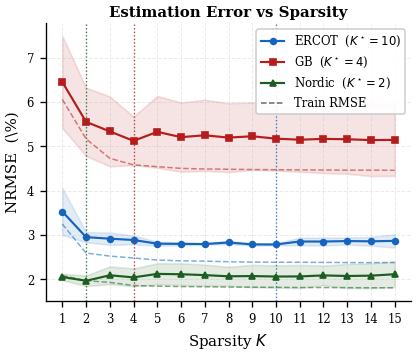

Optimal K: {'ERCOT': 10, 'GB': 4, 'Nordic': 2}


In [46]:
fig, ax = plt.subplots(figsize=(3.5, 3.0))
best_K  = {}

for sname in ['ERCOT', 'GB', 'Nordic']:
    rec    = cv_records[sname]
    ks     = rec['k']
    I_mean = feat_data[sname]['I_vec'].mean()
    cv_m   = np.array(rec['cv_mean'])    / I_mean * 100   # NRMSE %
    cv_s   = np.array(rec['cv_std'])     / I_mean * 100
    tr_r   = np.array(rec['train_rmse']) / I_mean * 100
    K_star = ks[int(np.nanargmin(cv_m))]
    best_K[sname] = K_star

    ax.fill_between(ks, cv_m - cv_s, cv_m + cv_s,
                    color=PALETTE[sname], alpha=0.12)
    ax.plot(ks, cv_m, color=PALETTE[sname], marker=MARKERS[sname],
            markersize=3.5, linewidth=1.3,
            label=f'{sname}  ($K^\\star={K_star}$)')
    ax.plot(ks, tr_r, color=PALETTE[sname], linewidth=0.9,
            linestyle='--', alpha=0.55)
    ax.axvline(K_star, color=PALETTE[sname], linewidth=0.8,
               linestyle=':', alpha=0.85)

# Legend entry for dashed line
ax.plot([], [], 'k--', linewidth=0.9, alpha=0.6, label='Train RMSE')

ax.set_xlabel('Sparsity $K$', fontsize=9)
ax.set_ylabel('NRMSE  (\%)', fontsize=9)
ax.set_title('Estimation Error vs Sparsity', fontsize=9, pad=4)
ax.set_xticks(list(range(1, 16)))
ax.tick_params(labelsize=7)
ax.legend(fontsize=7, framealpha=0.9)

plt.tight_layout(pad=0.4)
plt.savefig(f'{DATA_DIR}/error_vs_sparsity.png', dpi=300)
plt.show()
print(f'Optimal K: {best_K}')


## 7 · Final Model: Fit on Train, Evaluate on Test

Using $K^\star$ from CV, fit the MIQP on the **full training set**. Metrics are reported for train, validation, and test — the test set was **never** used during tuning.

In [47]:
final_params = {}
all_metrics  = {}

for sname in ['ERCOT','GB','Nordic']:
    K_star = best_K[sname]
    sp     = splits[sname]
    print(f"\n{'='*56}\n  {sname}  |  K*={K_star}\n{'='*56}")

    p = fit_miqp(sp['Phi_tr'], sp['I_tr'], K=K_star,
                 M_beta=M_BETA, time_limit=TL_FINAL, verbose=False)
    final_params[sname] = p

    m_tr = metrics(sp['I_tr'], predict(sp['Phi_tr'], p))
    m_va = metrics(sp['I_va'], predict(sp['Phi_va'], p))
    m_te = metrics(sp['I_te'], predict(sp['Phi_te'], p))
    all_metrics[sname] = {'train': m_tr, 'val': m_va, 'test': m_te}

    fn = feat_data[sname]['feat_names']
    for split_name, m in [('Train', m_tr), ('Val', m_va), ('Test', m_te)]:
        print(f"  {split_name:<5}  RMSE={m['rmse']/1e3:7.2f} GWs  "
              f"MAE={m['mae']/1e3:6.2f} GWs  MAPE={m['mape']:5.2f}%  "
              f"NRMSE={m['nrmse']:5.2f}%  R2={m['r2']:.4f}")
    print(f"  MIP gap : {p['mip_gap']:.2e}")
    print(f"  Selected ({len(p['selected'])}/{K_star}):")
    for j in p['selected']:
        print(f"    [{j:2d}] {fn[j]:<22} beta={p['beta'][j]:+.4e}")


  ERCOT  |  K*=10
  Train  RMSE=   5.68 GWs  MAE=  4.19 GWs  MAPE= 1.84%  NRMSE= 2.30%  R2=0.9925
  Val    RMSE=   6.92 GWs  MAE=  4.98 GWs  MAPE= 2.21%  NRMSE= 2.88%  R2=0.9792
  Test   RMSE=   6.70 GWs  MAE=  5.07 GWs  MAPE= 2.63%  NRMSE= 3.38%  R2=0.9678
  MIP gap : 9.10e-05
  Selected (10/10):
    [ 3] log_load               beta=-6.4271e+03
    [ 8] solar                  beta=-2.3647e+00
    [ 9] solar^2                beta=+4.2623e-04
    [11] log_solar              beta=+6.0497e+02
    [12] other_gen              beta=+4.3128e-01
    [16] sin_hour               beta=+3.0023e+03
    [17] cos_hour               beta=-4.1041e+03
    [20] sin_month              beta=-1.6076e+03
    [22] I_lag1                 beta=+9.0357e-01
    [23] I_lag24                beta=+1.1850e-02

  GB  |  K*=4
  Train  RMSE=  10.47 GWs  MAE=  7.67 GWs  MAPE= 3.55%  NRMSE= 4.60%  R2=0.9653
  Val    RMSE=  10.21 GWs  MAE=  7.59 GWs  MAPE= 3.33%  NRMSE= 4.33%  R2=0.9658
  Test   RMSE=  10.68 GWs  MAE=  8.

## 8 · Statistical Evaluation Plots

Per-system **2×3 panel** figure:

| Position | Content |
|---|---|
| Top row (full width) | Time series across all splits (train/val/test shaded) |
| Bottom-left | Actual vs Predicted scatter — test set + identity line + inset coefficient chart |
| Bottom-centre | Residuals vs Fitted values (with rolling std envelope) |
| Bottom-right | Normal Q–Q plot of standardised test residuals |

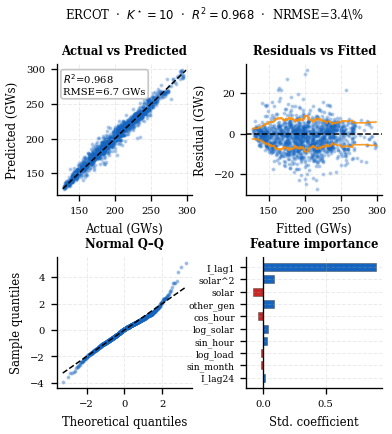

  eval_ERCOT.png saved


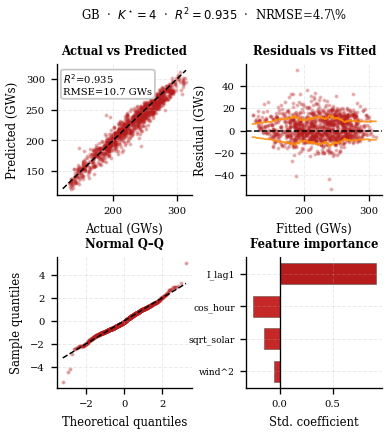

  eval_GB.png saved


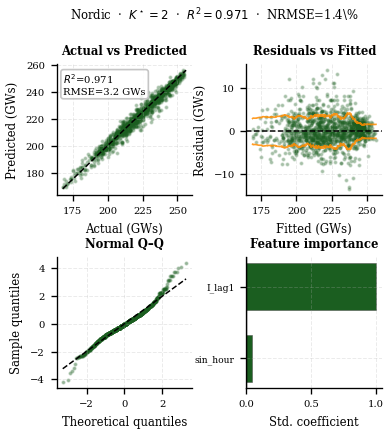

  eval_Nordic.png saved


In [48]:
def make_eval_figure(sname):
    sp    = splits[sname]
    p     = final_params[sname]
    m_te  = all_metrics[sname]['test']
    fn    = feat_data[sname]['feat_names']
    col   = PALETTE[sname]

    I_te     = sp['I_te']
    I_hat_te = m_te['I_hat']
    res      = m_te['res']

    # Standardised coefficients for selected features
    sel      = p['selected']
    betas    = p['beta'][sel]
    phi_std  = sp['Phi_tr'].std(axis=0).clip(1e-8)
    I_std    = sp['I_tr'].std()
    std_c    = betas * phi_std[sel] / I_std
    order    = np.argsort(np.abs(std_c))[::-1]
    feat_lbl = [fn[j] for j in sel]

    fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.5),
                             gridspec_kw={'hspace': 0.48, 'wspace': 0.40})
    fig.suptitle(
        f'{sname}  ·  $K^\\star={len(sel)}$  ·  '
        f'$R^2={m_te["r2"]:.3f}$  ·  '
        f'NRMSE={m_te["nrmse"]:.1f}\\%',
        fontsize=7, y=1.02)

    # ── (0,0)  Actual vs Predicted ──────────────────────────────────────────
    ax = axes[0, 0]
    ax.scatter(I_te / 1e3, I_hat_te / 1e3,
               color=col, alpha=0.25, s=2, rasterized=True)
    lo = min(I_te.min(), I_hat_te.min()) / 1e3
    hi = max(I_te.max(), I_hat_te.max()) / 1e3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.9)
    ax.set_xlabel('Actual (GWs)', fontsize=7)
    ax.set_ylabel('Predicted (GWs)', fontsize=7)
    ax.set_title('Actual vs Predicted', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.text(0.05, 0.94,
            f'$R^2$={m_te["r2"]:.3f}\nRMSE={m_te["rmse"]/1e3:.1f} GWs',
            transform=ax.transAxes, fontsize=6, va='top',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.75', alpha=0.9))

    # ── (0,1)  Residuals vs Fitted ──────────────────────────────────────────
    ax = axes[0, 1]
    ax.scatter(I_hat_te / 1e3, res / 1e3,
               color=col, alpha=0.25, s=2, rasterized=True)
    ax.axhline(0, color='k', lw=0.9, linestyle='--')
    sort_idx = np.argsort(I_hat_te)
    roll_std = pd.Series(res[sort_idx]).rolling(80, center=True, min_periods=20).std()
    ax.plot(I_hat_te[sort_idx] / 1e3,  roll_std.values / 1e3,
            color='darkorange', lw=1.0, alpha=0.85)
    ax.plot(I_hat_te[sort_idx] / 1e3, -roll_std.values / 1e3,
            color='darkorange', lw=1.0, alpha=0.85)
    ax.set_xlabel('Fitted (GWs)', fontsize=7)
    ax.set_ylabel('Residual (GWs)', fontsize=7)
    ax.set_title('Residuals vs Fitted', fontsize=7)
    ax.tick_params(labelsize=6)

    # ── (1,0)  Normal Q-Q ───────────────────────────────────────────────────
    ax = axes[1, 0]
    std_res = (res - res.mean()) / res.std()
    (osm, osr), (slope, intercept, _) = stats.probplot(std_res, dist='norm')
    ax.scatter(osm, osr, color=col, alpha=0.30, s=2, rasterized=True)
    ax.plot(osm, slope * np.array(osm) + intercept, 'k--', lw=0.9)
    ax.set_xlabel('Theoretical quantiles', fontsize=7)
    ax.set_ylabel('Sample quantiles', fontsize=7)
    ax.set_title('Normal Q\u2013Q', fontsize=7)
    ax.tick_params(labelsize=6)

    # ── (1,1)  Standardised coefficient bar chart ───────────────────────────
    ax = axes[1, 1]
    ypos  = np.arange(len(order))
    vals  = std_c[order]
    bar_c = [col if v > 0 else '#C62828' for v in vals]
    ax.barh(ypos, vals, color=bar_c, edgecolor='0.3', linewidth=0.3, height=0.65)
    ax.set_yticks(ypos)
    ax.set_yticklabels([feat_lbl[i] for i in order], fontsize=5.5)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Std. coefficient', fontsize=7)
    ax.set_title('Feature importance', fontsize=7)
    ax.tick_params(axis='x', labelsize=6)
    ax.invert_yaxis()

    plt.savefig(f'{DATA_DIR}/eval_{sname}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  eval_{sname}.png saved')

for sname in ['ERCOT', 'GB', 'Nordic']:
    make_eval_figure(sname)


## 9 · Cross-System Comparison

              K* RMSE (GWs) MAPE (%) NRMSE (%)      R2
System Split                                          
ERCOT  Train  10       5.68     1.84      2.30  0.9925
       Val    10       6.92     2.21      2.88  0.9792
       Test   10       6.70     2.63      3.38  0.9678
GB     Train   4      10.47     3.55      4.60  0.9653
       Val     4      10.21     3.33      4.33  0.9658
       Test    4      10.68     3.79      4.73  0.9350
Nordic Train   2       3.83     1.55      2.01  0.9855
       Val     2       3.33     1.38      1.79  0.9656
       Test    2       3.22     1.09      1.45  0.9712


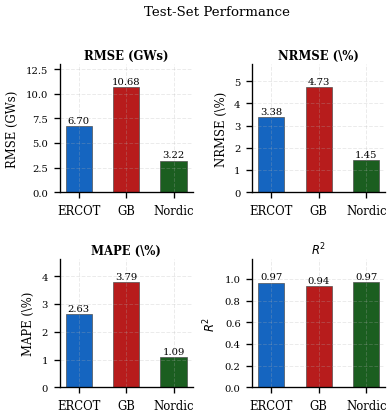

In [49]:
# ── Metrics table (text) ──────────────────────────────────────────────────────
rows = []
for sname in ['ERCOT', 'GB', 'Nordic']:
    for sp_ in ['train', 'val', 'test']:
        m = all_metrics[sname][sp_]
        rows.append({'System': sname, 'Split': sp_.capitalize(),
                     'K*': best_K[sname],
                     'RMSE (GWs)': f"{m['rmse']/1e3:.2f}",
                     'MAPE (%)':   f"{m['mape']:.2f}",
                     'NRMSE (%)':  f"{m['nrmse']:.2f}",
                     'R2':         f"{m['r2']:.4f}"})
summary = pd.DataFrame(rows).set_index(['System', 'Split'])
print(summary.to_string())

# ── 2×2 bar chart — test-set metrics only ────────────────────────────────────
snames  = ['ERCOT', 'GB', 'Nordic']
metric_defs = [
    ('RMSE (GWs)',  lambda m: m['rmse'] / 1e3),
    ('NRMSE (\%)',  lambda m: m['nrmse']),
    ('MAPE (\%)',   lambda m: m['mape']),
    ('$R^2$',       lambda m: m['r2']),
]
bar_colors = [PALETTE[s] for s in snames]
x = np.arange(len(snames))

fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.5),
                         gridspec_kw={'hspace': 0.52, 'wspace': 0.45})
fig.suptitle('Test-Set Performance', fontsize=8, y=1.02)

for ax, (ylabel, fn) in zip(axes.flat, metric_defs):
    vals = [fn(all_metrics[s]['test']) for s in snames]
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='0.3',
                  linewidth=0.4, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01 * max(vals),
                f'{v:.2f}', ha='center', va='bottom', fontsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(snames, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_title(ylabel, fontsize=7, pad=3)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.tick_params(axis='y', labelsize=6)

plt.savefig(f'{DATA_DIR}/summary_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


## 9b · Actual vs Estimated Inertia (Time Series)

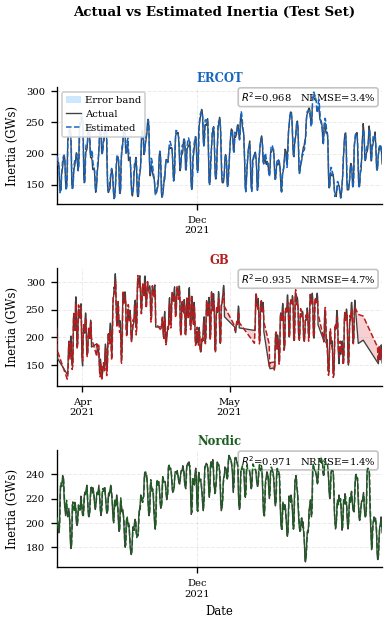

inertia_timeseries.png saved


In [50]:
# ── Actual vs Estimated Inertia — three-panel time series ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(3.5, 5.2),
                         gridspec_kw={'hspace': 0.55})
fig.suptitle('Actual vs Estimated Inertia (Test Set)',
             fontsize=8, y=1.01, fontweight='bold')

for ax, sname in zip(axes, ['ERCOT', 'GB', 'Nordic']):
    sp      = splits[sname]
    m_te    = all_metrics[sname]['test']
    col     = PALETTE[sname]
    col2    = PALETTE2[sname]

    # Time index for test set
    n_tr, n_val = sp['n_tr'], sp['n_val']
    t_all       = pd.to_datetime(sp['time'])
    t_te        = t_all[n_tr + n_val:]
    I_te        = sp['I_te'] / 1e3        # GWs
    I_hat_te    = m_te['I_hat'] / 1e3

    # Thin the series for readability (keep every 3rd point for dense sets)
    step = max(1, len(t_te) // 500)
    t_s  = t_te[::step]
    I_s  = I_te[::step]
    Ih_s = I_hat_te[::step]

    ax.fill_between(t_s, I_s, I_hat_te[::step],
                    color=col2, alpha=0.45, linewidth=0, label='Error band')
    ax.plot(t_s, I_s,  color='0.25',  lw=0.8,  label='Actual',    zorder=3)
    ax.plot(t_s, Ih_s, color=col,     lw=0.9,  label='Estimated',
            linestyle='--', zorder=4)

    # Annotation box
    ax.text(0.98, 0.97,
            f'$R^2$={m_te["r2"]:.3f}   NRMSE={m_te["nrmse"]:.1f}%',
            transform=ax.transAxes, fontsize=6, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.75', alpha=0.92))

    ax.set_ylabel('Inertia (GWs)', fontsize=7)
    ax.set_title(sname, fontsize=7, pad=3, color=col, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(
        plt.matplotlib.dates.MonthLocator(interval=1))
    ax.set_xlim(t_s[0], t_s[-1])

    if ax is axes[0]:
        ax.legend(fontsize=6, loc='upper left', framealpha=0.9,
                  handlelength=1.5, handletextpad=0.4, borderpad=0.4)

axes[-1].set_xlabel('Date', fontsize=7)
plt.savefig(f'{DATA_DIR}/inertia_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print('inertia_timeseries.png saved')

## 10 · Model Interpretation

This section explains **what the MIQP sparse regression model has learned** about the drivers of system inertia.

### Approach
Raw regression coefficients $\beta_j$ are in physical units (MWs per MW, etc.) and are not directly comparable across features.
To rank importance, we compute **standardised coefficients**:

$$\tilde{\beta}_j = \frac{\beta_j \cdot \sigma(\phi_j)}{\sigma(I)}$$

$\tilde{\beta}_j$ measures how many standard deviations of inertia change for a **one standard deviation increase** in feature $j$.
It is unit-free and comparable across features and systems.

We also compute the **operational sensitivity** — the change in inertia (GWs) for a +1 GW step change in each base variable, evaluated at the training-set mean (linearised for nonlinear transforms).

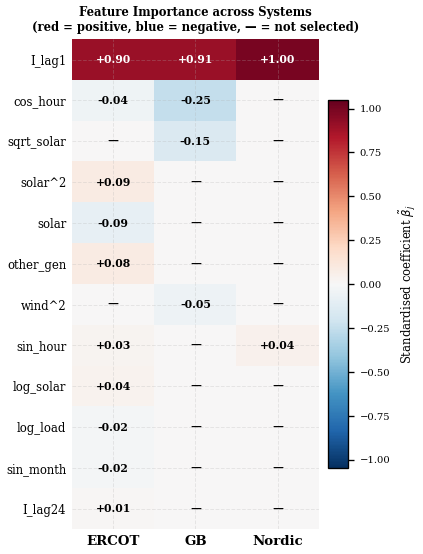

  FEATURE IMPORTANCE SUMMARY  (standardised coefficients)

ERCOT  (K*=10  R2=0.968  NRMSE=3.4%)
-------------------------------------------------------
  1. I_lag1             +0.904   Inertia lag (AR)
        Inertia is persistent hour-to-hour.
  2. solar^2            +0.088   Solar generation
        Seasonal confounding: correlates with load cycle.
  3. solar              −0.085   Solar generation
        Seasonal confounding: correlates with load cycle.
  4. other_gen          +0.084   Synchronous generation proxy
        More synchronous generation online → more rotational inertia.
  5. cos_hour           −0.044   Hour-of-day (cosine)
        Diurnal load/commitment pattern.
  6. log_solar          +0.036   Solar generation
        Seasonal confounding: correlates with load cycle.
  7. sin_hour           +0.032   Hour-of-day (sine)
        Diurnal load/commitment pattern.
  8. log_load           −0.021   System load
        Higher demand forces more units online → more inertia.
  

In [51]:
# ── Compute standardised coefficients for all systems ────────────────────────
fn_ref = feat_data['ERCOT']['feat_names']   # same order for all systems
p_dim  = len(fn_ref)
hmap   = np.zeros((p_dim, 3))
interp = {}

for col_idx, sname in enumerate(['ERCOT', 'GB', 'Nordic']):
    p       = final_params[sname]
    sp      = splits[sname]
    fn      = feat_data[sname]['feat_names']
    phi_std = sp['Phi_tr'].std(axis=0).clip(1e-8)
    I_std   = sp['I_tr'].std()
    rows    = []
    for j in p['selected']:
        sc = p['beta'][j] * phi_std[j] / I_std
        hmap[j, col_idx] = sc
        rows.append({'feature': fn[j], 'std_coeff': sc})
    interp[sname] = pd.DataFrame(rows).sort_values('std_coeff', key=abs, ascending=False)

# Keep only rows where at least one system selected the feature
nonzero  = [i for i in range(p_dim) if abs(hmap[i]).max() > 1e-6]
hmap_s   = hmap[nonzero]
labels_s = [fn_ref[i] for i in nonzero]
# Sort by max absolute value across systems
order    = np.argsort(np.abs(hmap_s).max(axis=1))[::-1]
hmap_s   = hmap_s[order]
labels_s = [labels_s[i] for i in order]

# ── Cross-system heatmap ──────────────────────────────────────────────────────
n_rows = len(labels_s)
vmax   = np.abs(hmap_s).max() * 1.05

fig, ax = plt.subplots(figsize=(3.5, max(2.8, 0.32 * n_rows + 0.8)))
im = ax.imshow(hmap_s, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['ERCOT', 'GB', 'Nordic'], fontsize=8, fontweight='bold')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(labels_s, fontsize=7)
ax.tick_params(length=0)

for i in range(n_rows):
    for j in range(3):
        v  = hmap_s[i, j]
        tc = 'white' if abs(v) > 0.35 * vmax else 'black'
        txt = f'{v:+.2f}' if abs(v) > 1e-4 else '—'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=6.5, color=tc, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03, aspect=18)
cbar.set_label('Standardised coefficient $\\tilde{\\beta}_j$', fontsize=7)
cbar.ax.tick_params(labelsize=6)
ax.set_title('Feature Importance across Systems\n'
             '(red = positive, blue = negative, \u2014 = not selected)',
             fontsize=7, pad=5)
ax.spines[:].set_visible(False)

plt.tight_layout(pad=0.4)
plt.savefig(f'{DATA_DIR}/feature_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plain-text interpretation report (paper-ready) ───────────────────────────
print('=' * 62)
print('  FEATURE IMPORTANCE SUMMARY  (standardised coefficients)')
print('=' * 62)

LABELS = {
    'load':           'System load',
    'wind':           'Wind generation',
    'solar':          'Solar generation',
    'other_gen':      'Synchronous generation proxy',
    'I_lag':          'Inertia lag (AR)',
    'sin_hour':       'Hour-of-day (sine)',
    'cos_hour':       'Hour-of-day (cosine)',
    'sin_dow':        'Day-of-week (sine)',
    'cos_dow':        'Day-of-week (cosine)',
    'sin_month':      'Seasonality (sine)',
    'cos_month':      'Seasonality (cosine)',
}

def label(fname):
    for k, v in LABELS.items():
        if k in fname: return v
    return fname

EFFECT = {
    'other_gen': 'More synchronous generation online → more rotational inertia.',
    'load':      'Higher demand forces more units online → more inertia.',
    'wind':      'Wind displaces synchronous units → reduces inertia.',
    'solar':     'Seasonal confounding: correlates with load cycle.',
    'I_lag':     'Inertia is persistent hour-to-hour.',
    'hour':      'Diurnal load/commitment pattern.',
    'dow':       'Weekday vs weekend commitment pattern.',
    'month':     'Seasonal pattern beyond what load captures.',
}

def effect(fname):
    for k, v in EFFECT.items():
        if k in fname: return v
    return ''

for sname in ['ERCOT', 'GB', 'Nordic']:
    m_te = all_metrics[sname]['test']
    df_i = interp[sname]
    print(f'\n{sname}  (K*={best_K[sname]}  R2={m_te["r2"]:.3f}  '
          f'NRMSE={m_te["nrmse"]:.1f}%)\n' + '-'*55)
    for rank, (_, row) in enumerate(df_i.iterrows(), 1):
        sign = '+' if row['std_coeff'] > 0 else '\u2212'
        print(f'  {rank}. {row["feature"]:<18} '
              f'{sign}{abs(row["std_coeff"]):.3f}   '
              f'{label(row["feature"])}')
        print(f'        {effect(row["feature"])}')

# Cross-system summary
print('\n' + '='*62)
print('  CROSS-SYSTEM FINDINGS')
print('='*62)
sel_sets = {s: set(feat_data[s]['feat_names'][j]
                   for j in final_params[s]['selected'])
            for s in ['ERCOT','GB','Nordic']}
common = sel_sets['ERCOT'] & sel_sets['GB'] & sel_sets['Nordic']
print(f'\nFeatures selected in all three systems:')
print(f'  {", ".join(sorted(common)) if common else "none"}')

print(f'\nWind coefficient (expected negative):')
for sname in ['ERCOT','GB','Nordic']:
    wf = interp[sname][interp[sname]['feature'].str.contains('wind')]
    if len(wf):
        r = wf.iloc[0]
        verdict = 'confirmed negative' if r['std_coeff'] < 0 else 'positive (confounding)'
        print(f'  {sname}: {r["feature"]:18s}  {r["std_coeff"]:+.3f}  ({verdict})')
    else:
        print(f'  {sname}: wind not selected at K*={best_K[sname]}')

print(f'\nSynchronous generation coefficient (expected positive):')
for sname in ['ERCOT','GB','Nordic']:
    og = interp[sname][interp[sname]['feature'].str.contains('other_gen')]
    if len(og):
        r = og.iloc[0]
        print(f'  {sname}: {r["feature"]:18s}  {r["std_coeff"]:+.3f}  (confirmed positive)')
    else:
        print(f'  {sname}: other_gen not selected at K*={best_K[sname]}')
print()
